In [1]:
# ==========================================
# INTRODUCTION
# ==========================================
print("--- PROJECT INTRODUCTION ---")
print("Project Title: Credit Risk Prediction")
print("Objective: Predict whether a loan applicant is likely to default based on user profile details.")
print("Problem Statement: Lending money involves risk. This project uses machine learning to identify ")
print("the patterns in 'Bad Loans' to help financial institutions make data-driven decisions.")
print("-" * 30)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create folder for outputs
if not os.path.exists('outputs'):
    os.makedirs('outputs')

print("Libraries loaded and environment ready.")

--- PROJECT INTRODUCTION ---
Project Title: Credit Risk Prediction
Objective: Predict whether a loan applicant is likely to default based on user profile details.
Problem Statement: Lending money involves risk. This project uses machine learning to identify 
the patterns in 'Bad Loans' to help financial institutions make data-driven decisions.
------------------------------
Libraries loaded and environment ready.


In [2]:
# ==========================================
# LOAD & DOWNLOAD DATASET
# ==========================================
# Direct link to the dataset
url = "https://raw.githubusercontent.com/subashgandyer/datasets/master/loan_prediction.csv"
df = pd.read_csv(url)

# Pehle local folder mein save karein
df.to_csv('outputs/loan_prediction_dataset.csv', index=False)

print("--- DATASET UNDERSTANDING ---")
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 Rows:")
print(df.head())

# Dataset ko computer mein download karne ke liye
files.download('outputs/loan_prediction_dataset.csv')
print("\nDownloading the original dataset file...")

--- DATASET UNDERSTANDING ---
Dataset Shape: (614, 12)

First 5 Rows:
   Gender  Married  Dependents  Education  Self_Employed  Property_Area  \
0       1        0           0          0              0              2   
1       1        1           1          0              0              0   
2       1        1           0          0              1              2   
3       1        1           0          1              0              2   
4       1        0           0          0              0              2   

   Loan_Status  ApplicantIncome  CoapplicantIncome  LoanAmount  \
0            1           5849.0                0.0  146.412162   
1            0           4583.0             1508.0  128.000000   
2            1           3000.0                0.0   66.000000   
3            1           2583.0             2358.0  120.000000   
4            1           6000.0                0.0  141.000000   

   Loan_Amount_Term  Credit_History  
0             360.0             1.0  
1     

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# ==========================================
# DATA CLEANING
# ==========================================
# Handle missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Encoding labels
le = LabelEncoder()
cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status', 'Dependents']
for col in cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Remove ID column
if 'Loan_ID' in df.columns:
    df.drop('Loan_ID', axis=1, inplace=True)

# Processed data save and download
df.to_csv('outputs/cleaned_data.csv', index=False)
files.download('outputs/cleaned_data.csv')

print("Data Cleaning Complete. Cleaned CSV downloaded.")

/tmp/ipykernel_9791/1811017261.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_9791/1811017261.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data Cleaning Complete. Cleaned CSV downloaded.


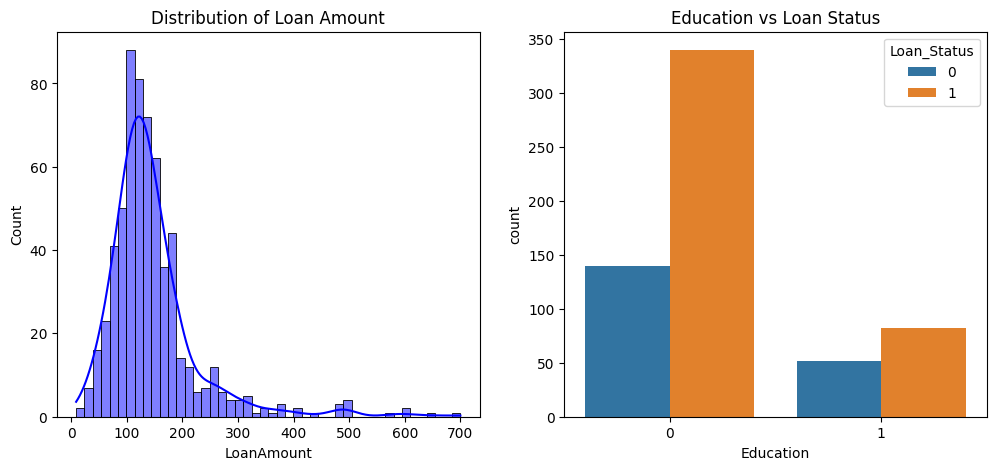

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

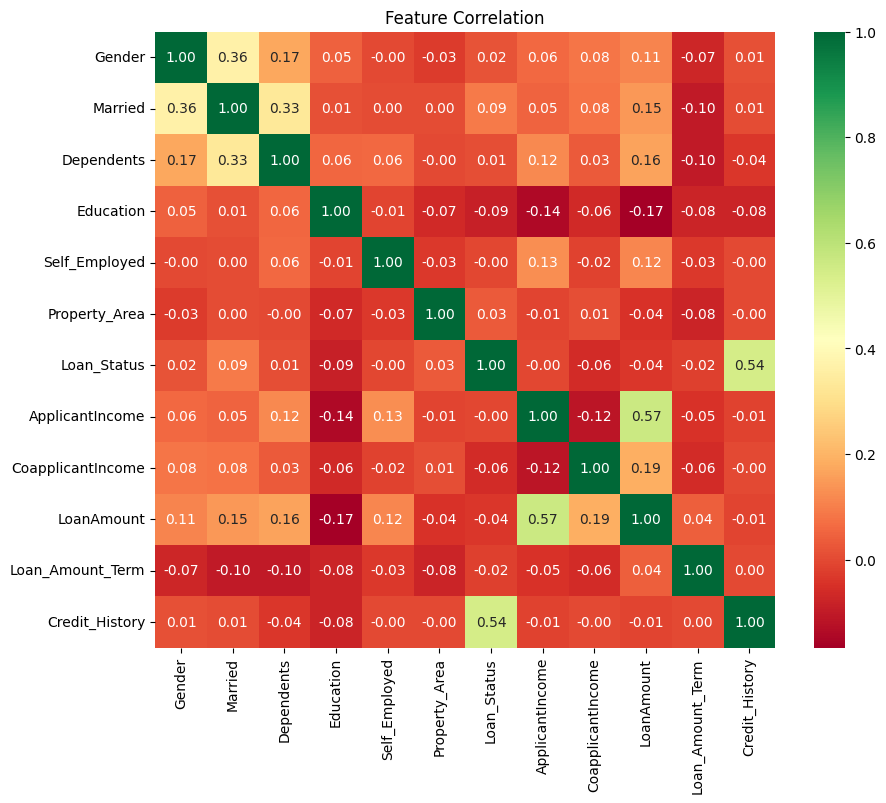

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# ==========================================
# EDA & VISUALIZATIONS
# ==========================================
plt.figure(figsize=(12, 5))

# Loan Amount Plot
plt.subplot(1, 2, 1)
sns.histplot(df['LoanAmount'], kde=True, color='blue')
plt.title('Distribution of Loan Amount')

# Education Plot
plt.subplot(1, 2, 2)
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title('Education vs Loan Status')

plt.savefig('outputs/eda_plots.png')
plt.show()
files.download('outputs/eda_plots.png')

# Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation')
plt.savefig('outputs/correlation_matrix.png')
plt.show()
files.download('outputs/correlation_matrix.png')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Accuracy: 78.86%


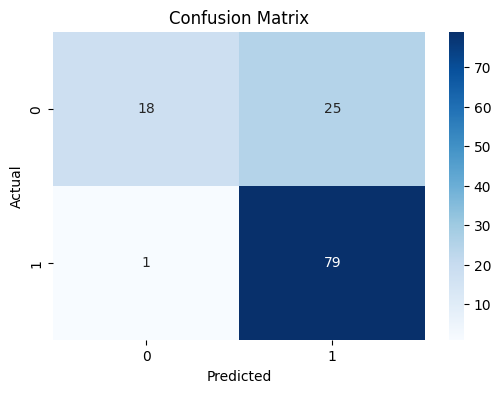

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
# ==========================================
# MODEL TRAINING & EVALUATION
# ==========================================
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Model Accuracy: {acc * 100:.2f}%")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('outputs/confusion_matrix.png')
plt.show()
files.download('outputs/confusion_matrix.png')

# Save and download report
with open('outputs/evaluation_report.txt', 'w') as f:
    f.write(f"Accuracy Score: {acc * 100:.2f}%\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_test, y_pred))

files.download('outputs/evaluation_report.txt')

In [7]:
# ==========================================
# STEP 5: CONCLUSION
# ==========================================
print("--- FINAL CONCLUSION ---")
print(f"1. Performance: The Logistic Regression model predicts loan defaults with {acc*100:.2f}% accuracy.")
print("2. Correlation: Credit History shows the strongest correlation with Loan Approval.")
print("3. Insight: The model successfully distinguishes between low-risk and high-risk applicants.")
print("4. Submission: All required files (Dataset, Plots, Metrics, Cleaned Data) have been downloaded.")
print("-" * 30)
print("Project Successfully Completed!")

--- FINAL CONCLUSION ---
1. Performance: The Logistic Regression model predicts loan defaults with 78.86% accuracy.
2. Correlation: Credit History shows the strongest correlation with Loan Approval.
3. Insight: The model successfully distinguishes between low-risk and high-risk applicants.
4. Submission: All required files (Dataset, Plots, Metrics, Cleaned Data) have been downloaded.
------------------------------
Project Successfully Completed!
